# Oil Import Prediction

Nama: Yudha nuur cahyo

NIM: 220411100052

Mata Kuliah: Proyek sains Data

Notebook ini berisi proses analisis data time series untuk memprediksi impor minyak dunia ke Amerika Serikat menggunakan model Bagging Regressor dengan Linear Regression sebagai estimasi dasar. Proses dimulai dengan mengimpor pustaka yang dibutuhkan seperti numpy, pandas, matplotlib, dan sklearn, diikuti dengan membaca dataset impor minyak.

Langkah berikutnya adalah melakukan preprocessing data dengan mengonversi kolom tanggal ke format datetime, menambahkan kolom tahun dan bulan, serta memvisualisasikan data time series untuk memahami pola tren. Data kemudian diolah menggunakan metode sliding window untuk membentuk data input (X) dan target (y), di mana 4 data terakhir digunakan untuk memprediksi data berikutnya.

Selanjutnya, data dinormalisasi menggunakan MinMaxScaler untuk memastikan nilai berada dalam rentang 0 hingga 1. Model dilatih menggunakan Bagging Regressor dengan Linear Regression sebagai estimator dasar, dan dilakukan evaluasi terhadap model menggunakan metrik seperti Mean Squared Error (MSE), Root Mean Squared Error (RMSE), dan Mean Absolute Percentage Error (MAPE).

Hasil prediksi dibandingkan dengan data aktual untuk menilai performa model, dan visualisasi dibuat untuk membantu memahami hasil prediksi. Notebook ini memberikan gambaran lengkap mengenai pengolahan data, pelatihan model, evaluasi, dan prediksi dalam konteks analisis time series.

In [1]:
import numpy as np

## Memahami Data ( Data Undertanding)

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pickle
import pandas as pd

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/My Drive/psd/tugas/dataset/Imports Oil.csv")

In [4]:
data

,Date and Month,Crude oil imports from the World to the US (a thousand barrels)
0,2009 01,317275
1,2009 02,262339
2,2009 03,303897
3,2009 04,285934
4,2009 05,281147
...,...,...
140,2020 09,161926
141,2020 10,164494
142,2020 11,168655
143,2020 12,178597


## Praproses data ( Preprocessing data)

### Mengubah kolom Date and Month menjadi format datetime.

In [5]:
# Preprocessing
data['Date and Month'] = pd.to_datetime(data['Date and Month'])
data['Year'] = data['Date and Month'].dt.year
data['Month'] = data['Date and Month'].dt.month

<ipython-input-5-01c4818ce047>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date and Month'] = pd.to_datetime(data['Date and Month'])


In [6]:
print(data.describe())

                      Date and Month  \
count                            145   
mean   2014-12-31 10:25:39.310344704   
min              2009-01-01 00:00:00   
25%              2012-01-01 00:00:00   
50%              2015-01-01 00:00:00   
75%              2018-01-01 00:00:00   
max              2021-01-01 00:00:00   
std                              NaN   

       Crude oil imports from the World to the US (a thousand barrels)  \
count                                         145.000000                 
mean                                       240900.606897                 
min                                        161926.000000                 
25%                                        221130.000000                 
50%                                        239212.000000                 
75%                                        265615.000000                 
max                                        318991.000000                 
std                                         344

Menampilkan statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dll., untuk kolom numerik dalam DataFrame.

### Menghitung jumlah nilai kosong

In [7]:
print(data.isnull().sum())

Date and Month                                                     0
Crude oil imports from the World to the US (a thousand barrels)    0
Year                                                               0
Month                                                              0
dtype: int64


### Membuat grafik time series untuk menunjukkan tren impor minyak dari waktu ke waktu.

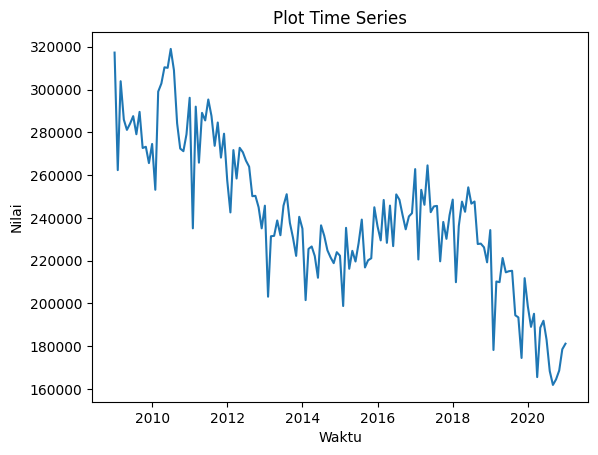

In [8]:
import matplotlib.pyplot as plt

# Visualisasi data time series
plt.plot(data['Date and Month'], data['Crude oil imports from the World to the US (a thousand barrels)'])
plt.title('Plot Time Series')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()


### Mengambil kolom nilai impor minyak dalam bentuk array numpy untuk digunakan dalam analisis.

In [9]:
# Mengambil kolom harga dan mengubahnya menjadi array numpy
prices = data['Crude oil imports from the World to the US (a thousand barrels)'].values
print(prices)

[317275 262339 303897 285934 281147 284093 287569 279111 289561 272678
 273248 265615 274568 253150 299033 302836 310396 310153 318991 309053
 284192 272415 271185 279096 296158 235122 292010 265822 289106 285572
 295338 287633 273698 284594 268189 279359 257536 242560 271697 258417
 272766 270684 266782 263945 250160 250303 244987 235120 245715 203162
 231414 231621 238809 231912 245724 251079 237699 230822 222248 240519
 234969 201572 225487 226639 222177 212025 236534 231649 224851 221600
 218845 223978 222315 198807 235360 216229 224604 219618 228160 239212
 216838 220171 221130 244965 236065 229492 248383 228344 245749 226802
 250986 248482 241213 234666 240691 242213 262811 220558 253114 246132
 264554 242677 245369 245611 219708 238109 230230 241245 248552 209942
 236216 247608 242857 254283 246671 247656 227795 227975 226251 219240
 234307 178257 210276 209958 221259 214563 215083 215273 194485 193493
 174531 211837 198663 189060 195181 165586 188693 191919 183087 168406
 16192

### melakukan sliding window

In [10]:
def sliding_window(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 4  # Ukuran jendela =3
X, y = sliding_window(prices, window_size)
print("X:", X)
print("y:", y)

X: [[317275 262339 303897 285934]
 [262339 303897 285934 281147]
 [303897 285934 281147 284093]
 [285934 281147 284093 287569]
 [281147 284093 287569 279111]
 [284093 287569 279111 289561]
 [287569 279111 289561 272678]
 [279111 289561 272678 273248]
 [289561 272678 273248 265615]
 [272678 273248 265615 274568]
 [273248 265615 274568 253150]
 [265615 274568 253150 299033]
 [274568 253150 299033 302836]
 [253150 299033 302836 310396]
 [299033 302836 310396 310153]
 [302836 310396 310153 318991]
 [310396 310153 318991 309053]
 [310153 318991 309053 284192]
 [318991 309053 284192 272415]
 [309053 284192 272415 271185]
 [284192 272415 271185 279096]
 [272415 271185 279096 296158]
 [271185 279096 296158 235122]
 [279096 296158 235122 292010]
 [296158 235122 292010 265822]
 [235122 292010 265822 289106]
 [292010 265822 289106 285572]
 [265822 289106 285572 295338]
 [289106 285572 295338 287633]
 [285572 295338 287633 273698]
 [295338 287633 273698 284594]
 [287633 273698 284594 268189]
 [273

Mendefinisikan fungsi sliding_window untuk membuat data input (X) dan target (y) menggunakan metode jendela geser.

### normalisasi data

In [11]:
from sklearn.preprocessing import MinMaxScaler
X, y = sliding_window(prices, window_size)

# Normalisasi data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Lakukan fit dan transformasi pada X dan y
X_normalized = scaler_X.fit_transform(X)
y_normalized = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print("X setelah normalisasi:\n", X_normalized)
print("y setelah normalisasi:\n", y_normalized)

X setelah normalisasi:
 [[0.98907459 0.63930857 0.90389966 0.789533  ]
 [0.63930857 0.90389966 0.789533   0.75905517]
 [0.90389966 0.789533   0.75905517 0.77781173]
 [0.789533   0.75905517 0.77781173 0.7999427 ]
 [0.75905517 0.77781173 0.7999427  0.74609238]
 [0.77781173 0.7999427  0.74609238 0.81262535]
 [0.7999427  0.74609238 0.81262535 0.70513482]
 [0.74609238 0.81262535 0.70513482 0.70876389]
 [0.81262535 0.70513482 0.70876389 0.66016617]
 [0.70513482 0.70876389 0.66016617 0.71716805]
 [0.70876389 0.66016617 0.71716805 0.58080413]
 [0.66016617 0.71716805 0.58080413 0.87293159]
 [0.71716805 0.58080413 0.87293159 0.89714449]
 [0.58080413 0.87293159 0.89714449 0.94527743]
 [0.87293159 0.89714449 0.94527743 0.9437303 ]
 [0.89714449 0.94527743 0.9437303  1.        ]
 [0.94527743 0.9437303  1.         0.93672683]
 [0.9437303  1.         0.93672683 0.77844205]
 [1.         0.93672683 0.77844205 0.70346035]
 [0.93672683 0.77844205 0.70346035 0.6956292 ]
 [0.77844205 0.70346035 0.6956292  0

- Menggunakan MinMaxScaler untuk normalisasi data agar berada dalam rentang 0-1.
- Normalisasi dilakukan pada data input (X) dan target (y).

### Membagi data menjadi set latih dan uji

In [12]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Bagi data menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi model Linear Regression sebagai estimator
base_estimator = LinearRegression()

# Membuat model Bagging Regressor dengan Linear Regression sebagai estimator
# Use 'estimator' instead of 'base_estimator' for older versions of scikit-learn
model = BaggingRegressor(estimator=base_estimator, n_estimators=10, random_state=42)

# Melatih model
model.fit(X_train, y_train)

# Melakukan prediksi
y_pred = model.predict(X_test)

# Mengukur performa model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("Prediksi:", y_pred)

Mean Squared Error (MSE): 248950101.55948818
Prediksi: [220957.29923959 235881.2075715  272571.19062021 235458.19489098
 237182.19792772 174388.75422306 231842.92780407 230925.10396024
 189730.11598214 285106.44453365 281019.10545697 239256.38211118
 272045.53383377 239573.71440915 246539.46904704 170104.78480801
 279136.75807898 182875.28435362 267681.97831034 209005.28337935
 221510.95796296 241138.53423862 201849.79357889 238326.40799589
 224916.8100163  277706.40634581 222940.41866685 250421.9659555
 245246.04728163]


- Membagi data menjadi set latih dan uji (80%-20%).
- Melatih model BaggingRegressor dengan LinearRegression sebagai estimasi dasar.
- Mengukur kinerja model menggunakan Mean Squared Error (MSE).

## Modelling

### Melatih model BaggingRegressor

In [13]:
# mmenggunakan linearRegression
from sklearn.linear_model import LinearRegression

linear= LinearRegression()
bagging_model3 = BaggingRegressor(estimator=linear, n_estimators=10, random_state=42)

# Melatih model pada data
bagging_model3.fit(X, y)

BaggingRegressor(estimator=LinearRegression(), random_state=42)

## Evaluasi

### melakukan uji coba pada model yang di latih untuk melakukan prediksi

In [14]:
y_pred3 = bagging_model3.predict(X)

# Prediksi pada data training untuk menghitung RMSE
rmse3 = np.sqrt(mean_squared_error(y, y_pred3))
print("RMSE:", rmse3)

# Menghitung MAPE
mape3 = np.mean(np.abs((y - y_pred3) / y)) * 100

# Menampilkan MAPE dalam bentuk persen dengan 2 desimal
print(f"MAPE: {mape3:.2f}%")

RMSE: 14712.61894889046
MAPE: 4.87%


In [15]:
# Data input untuk prediksi (minggu ke-39 sampai ke-41)
# Adjust the window size to match the training data
# new_data = np.array([prices[-2:]])  # Mengambil 4 minggu terakhir untuk konsistensi fitur
new_data = np.array([prices[-window_size:]]) # Mengambil 4 data terakhir untuk konsistensi fitur, sesuai dengan window_size yang digunakan saat training

# Prediksi
predicted_price3 = bagging_model3.predict(new_data.reshape(1, -1)) # Reshape new_data to have the correct dimensions (1 sample, 4 features)
print("Prediksi menggunakan linear regression :", predicted_price3)

Prediksi menggunakan linear regression : [179059.57986068]


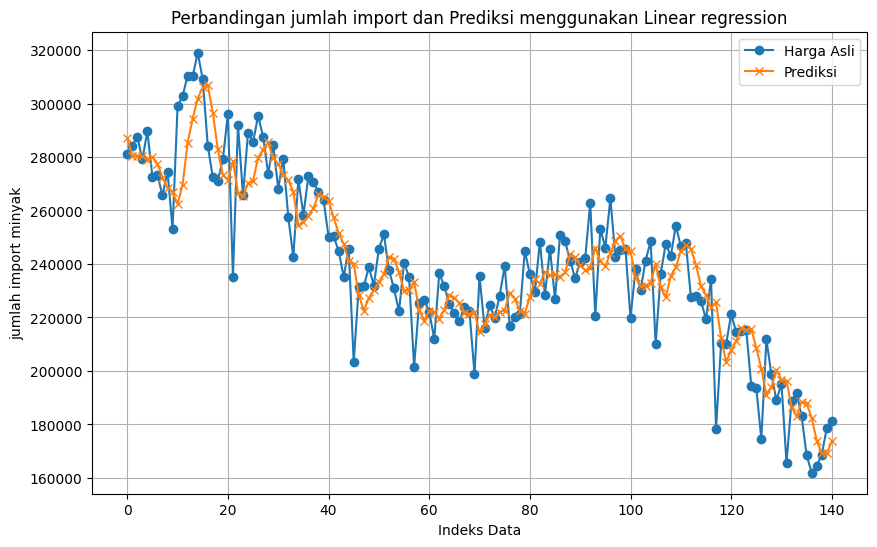

In [18]:
# 6. Visualisasi Hasil (Opsional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(len(y)), y, label='Harga Asli', marker='o')
plt.plot(range(len(y_pred3)), y_pred3, label='Prediksi', marker='x')
plt.xlabel('Indeks Data')
plt.ylabel('jumlah import minyak')
plt.title('Perbandingan jumlah import dan Prediksi menggunakan Linear regression')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import pickle

# Misalnya model prediksi Anda bernama 'model' dan telah dilatih
# Ganti 'model' dengan nama variabel model Anda

model_filename = 'import_oil_model.pkl'

# Simpan model menggunakan pickle
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model berhasil disimpan dalam file: {model_filename}")


Model berhasil disimpan dalam file: import_oil_model.pkl


## Hasil Deploy

ini adalah hasil deploy untuk prediksi ini :
https://huggingface.co/spaces/yudhanuurcahyo/psd_prediksi_tugas2
